In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))

from tqdm import tqdm
from ml_force import MorrisLecarCurrent, z_transform, LorenzAttractor

In [2]:
T = 10000
dt = 1e-1
t = np.arange(0, T, dt)
nt = t.size

In [4]:
supervisor = LorenzAttractor(T, dt, tau=0.01).generate(transient_time=500)

supervisor = z_transform(supervisor.T)

(100000, 3)


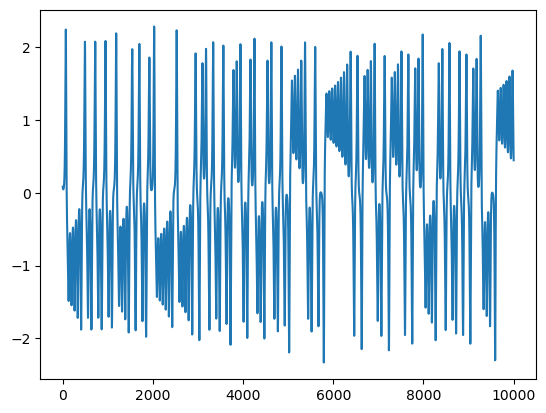

In [5]:
print(supervisor.shape)
plt.plot(t, supervisor[:, 0])
plt.show()

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dtype = torch.float32
sup_tensor = torch.tensor(supervisor, device=device, dtype=dtype)

x_axes = [0]
y_axes = [1, 2]


nt_train = int(nt * .6)
sup_train = sup_tensor[:nt_train, :]
sup_test = sup_tensor[nt_train:, :]
x_train, y_train = sup_train[:, x_axes], sup_train[:, y_axes]
x_test, y_test = sup_test[:, x_axes], sup_test[:, y_axes]

In [8]:
Ne = 500
Ni = 500
N = Ne + Ni

I = 70      # pA
gbar = 20
Q = 100
delta = 1.0
p_sparse = .01

## Echo State with SNN

In [9]:
from typing import Literal, Union

class ML_ESN(torch.nn.Module):
    def __init__(
        self,
        model_cls:MorrisLecarCurrent,
        n_input:int, n_output:int,
        ne_hidden:int=500, ni_hidden:int=500,
        BIAS:Union[torch.Tensor, np.ndarray, float]=75,     # pA
        w_res_amp:float=20, w_in_amp:float=200.0,
        T:float=1000.0, dt:float=1e-1,
        dtype=torch.float32, device=torch.device('cpu')
        ) -> None:
        super().__init__()
        
        self.n_input = n_input
        self.n_output = n_output
        self.ne_hidden = ne_hidden
        self.ni_hidden = ni_hidden
        self.n_hidden = ni_hidden + ne_hidden
        self.dtype = dtype
        self.device = device
        self.BIAS = BIAS
        self.mlc = model_cls(
            supervisor=np.zeros((self.n_hidden, self.n_input)),
            Ne=ne_hidden, Ni=ni_hidden,
            gbar=w_res_amp, Q=w_in_amp,
            p_sparsity=0.01, device=device,
            BIAS=BIAS,T=T, dt=dt
            )
        
        self.W_in = w_in_amp * (2 * torch.rand((self.n_hidden, self.n_input), dtype=self.dtype, device=device) - 1)
        self.mlc.eta = self.W_in.clone().detach()
        self.W_out = torch.zeros((self.n_hidden, self.n_hidden), dtype=dtype, device=device)
    
    def forward(self, x:torch.Tensor, nt_transient:int=500, closed_loop:bool=False):
        nt = x.size(0)
        
        if closed_loop and self.n_input != self.n_output:
            raise ValueError("In closed loop model, `n_input` must equal `n_output`.")

        # Record the state of the system
        h_rec = torch.zeros((nt, self.n_hidden), dtype=self.dtype, device=self.mlc.device)
        
        self.mlc._BIAS = self.BIAS
        for i in tqdm(range(nt_transient)):
            self.mlc.euler_step()
        
        inp_current = 0.0
        for i in tqdm(range(nt)):
            if not closed_loop:
                inp_current = self.W_in @ x[i].reshape(-1, 1)
            self.mlc._BIAS = self.BIAS + inp_current
            self.mlc.euler_step(closed_loop=closed_loop)
            h_rec[i] = self.mlc.s.clone().squeeze()

        return h_rec
    
    def fit(
        self, x:torch.Tensor, y:torch.Tensor=None, nt_transient:int=500, 
        closed_loop:bool=False, l_ridge:float=1e-5
        ) -> torch.Tensor:
        """
        x: (nt, n_input)
        y: (nt, n_output)
        """
        if not closed_loop and y is None:
            raise ValueError("In open loop model, must provide `y`")
        
        h_rec = self.forward(x, closed_loop=False, nt_transient=nt_transient)  # forward task for training is open loop
        Pinv = torch.linalg.pinv(
            h_rec.T @ h_rec + l_ridge * torch.eye(self.n_hidden, device=self.device, dtype=self.dtype)
        )
        if closed_loop:
            self.W_out = Pinv @ h_rec.T @ x
            self.mlc.dec = self.W_out.clone().detach()
        else:
            self.W_out.data = Pinv @ h_rec.T @ y
            self.mlc.dec = self.W_out.clone().detach()
        return h_rec
        
    def predict(self, x:torch.Tensor, closed_loop:bool=False) -> torch.Tensor:
        """
        x: (nt, n_input)
        """        
        h_rec = self.forward(x, closed_loop=closed_loop, nt_transient=0)
        y_hat = h_rec @ self.W_out
        return y_hat.clone().detach()

In [ ]:
mlc_esn = ML_ESN(
    MorrisLecarCurrent, n_input=len(x_axes), n_output=len(y_axes),
    BIAS=I, ne_hidden=Ne, ni_hidden=Ni, w_in_amp=Q, w_res_amp=gbar, device=device
    )

mlc_h_rec = mlc_esn.fit(x_train, y_train, l_ridge=1e-5, nt_transient=int(500/dt))

In [ ]:
y_hat_mlc = mlc_esn.predict(x_test)

In [ ]:
t_test = t[nt_train:]

fig, ax = plt.subplots(figsize=(10, 8), nrows=len(y_axes), sharex=True)
ax[0].set_title(f"SNN, {mlc_esn.n_hidden} Neurons")

for i_ax in range(len(ax)):
    ax[i_ax].plot(t_test, y_test[:, i_ax].cpu().numpy(), 'b-', label='y')
    ax[i_ax].plot(t_test, y_hat_mlc[:, i_ax].cpu().numpy(), 'r-', label=r'$\hat{y}$')
    ax[i_ax].legend(loc='upper right')
plt.show()

## Echo State with ANNs

In [ ]:
class ANN_ESN(torch.nn.Module):
    def __init__(
        self, n_hidden:int=200, n_output:int=1, n_input:int=1,
        device=None, w_in_amp:float=100.0, w_res_amp:float=2.0, dtype=torch.float32
        ) -> None:
        super(ANN_ESN, self).__init__()
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.n_input = n_input
        self.device = device
        self.dtype = dtype
        self.W_in = torch.nn.Parameter(
            (2 * torch.rand(n_hidden, n_input, dtype=dtype, device=device) - 1) * w_in_amp,
            requires_grad=False
            )
        self.W_out = torch.nn.Parameter(torch.zeros((n_hidden, n_output), device=device, dtype=self.dtype))
        self.W_res = torch.nn.Parameter(
            torch.randn(n_hidden, n_hidden, dtype=self.dtype, device=device) * w_res_amp,
            requires_grad=False
            )
    
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        """
        x: (nt, n_input)
        """
        nt = x.size(0)
        h_rec = torch.zeros((nt, self.n_hidden), device=self.device, dtype=self.dtype)
        h = torch.zeros((self.n_hidden, 1), device=self.device, dtype=self.dtype)
        for i in tqdm(range(nt)):
            h = torch.sigmoid(
                self.W_in @ x[i].unsqueeze(1) + self.W_res @ h
                ).clone().detach()
            h_rec[i] = h.squeeze()
        return h_rec.clone().detach()
    
    def fit(self, x:torch.Tensor, y:torch.Tensor, l_ridge:float=1e-5) -> None:
        """
        x: (nt, n_input)
        y: (nt, n_output)
        """
        h_rec = self.forward(x)
        Pinv = torch.linalg.pinv(
            h_rec.T @ h_rec + l_ridge * torch.eye(self.n_hidden, device=self.device, dtype=self.dtype)
        )
        self.W_out.data = Pinv @ h_rec.T @ y
        
    def predict(self, x:torch.Tensor) -> torch.Tensor:
        """
        x: (nt, n_input)
        """
        h_rec = self.forward(x)
        y_hat = h_rec @ self.W_out
        return y_hat.clone().detach()
    

In [10]:
class ANN_ESN(torch.nn.Module):
    def __init__(
        self, n_hidden:int=200, n_output:int=1, n_input:int=1,
        device=None, w_in_amp:float=100.0, w_res_amp:float=2.0, dtype=torch.float32,
        bias:float=75.0) -> None:
        super(ANN_ESN, self).__init__()
        self.n_hidden = n_hidden
        self.n_output = n_output
        self.n_input = n_input
        self.bias = bias
        self.device = device
        self.dtype = dtype
        self.W_in = torch.nn.Parameter(
            (2 * torch.rand(n_hidden, n_input, dtype=dtype, device=device) - 1) * w_in_amp,
            requires_grad=False
            )
        self.W_out = torch.zeros((n_hidden, n_output), device=device, dtype=self.dtype)
        self.W_res = torch.nn.Parameter(
            torch.randn(n_hidden, n_hidden, dtype=self.dtype, device=device) * w_res_amp,
            requires_grad=False
            )
        # self.W_res /= torch.linalg.eigvals(self.W_res.data).abs().max().item() * 1.2
        # self.W_res.data *= w_res_amp
    
    def forward(self, x:torch.Tensor, h_init:torch.Tensor=None, closed_loop:bool=False) -> torch.Tensor:
        """
        x: (nt, n_input)
        """
        if closed_loop and self.n_input != self.n_output:
            raise ValueError("In closed loop format, `n_input` must be equal to `n_ouput`.")
        
        W_total = None
        if closed_loop:
            W_total = self.W_in @ self.W_out.T + self.W_res
            print(W_total.size())

        nt = x.size(0)
        h_rec = torch.zeros((nt, self.n_hidden), device=self.device, dtype=self.dtype)
        h = torch.zeros((self.n_hidden, 1), device=self.device, dtype=self.dtype)
        if h_init is not None:
            h = h_init.clone()
        
        for i in tqdm(range(nt)):
            if closed_loop:
                h = torch.tanh(
                    W_total @ h + self.bias
                )
            else:
                h = torch.tanh(
                    self.W_in @ x[i].unsqueeze(1) + self.W_res @ h + self.bias
                    )
            h_rec[i] = h.squeeze()
        return h_rec
    
    def fit(self, x:torch.Tensor, y:torch.Tensor=None, closed_loop:bool=False, l_ridge:float=1e-5) -> torch.Tensor:
        """
        x: (nt, n_input)
        y: (nt, n_output)
        """
        if not closed_loop and y is None:
            raise ValueError("In open loop model, must provide `y`")
        
        h_rec = self.forward(x, closed_loop=False)  # forward task for training is open loop
        Pinv = torch.linalg.pinv(
            h_rec.T @ h_rec + l_ridge * torch.eye(self.n_hidden, device=self.device, dtype=self.dtype)
        )
        if closed_loop:
            self.W_out.data = Pinv @ h_rec.T @ x
        else:
            self.W_out.data = Pinv @ h_rec.T @ y
        return h_rec
        
    def predict(self, x:torch.Tensor, h_init:torch.Tensor=None, closed_loop:bool=False) -> torch.Tensor:
        """
        x: (nt, n_input)
        """
        if closed_loop and h_init is None:
            raise ValueError("In closed loop, must provide the last value of `h_rec` as `h_init`.")
        
        h_rec = self.forward(x, h_init=h_init, closed_loop=closed_loop)
        y_hat = h_rec @ self.W_out
        return y_hat.clone().detach()

In [11]:
ann_res = ANN_ESN(
    n_hidden=1000, n_output=len(y_axes), n_input=len(x_axes),
    device=device, dtype=torch.float32,
    w_in_amp=.2, w_res_amp=.04, bias=0.2
    )

In [12]:
ann_h_rec = ann_res.fit(x_train, y_train)

100%|██████████| 60000/60000 [00:05<00:00, 10431.76it/s]


In [13]:
ann_h_rec[-1]

tensor([ 9.2692e-01,  8.1624e-01,  8.8036e-02,  6.4169e-01,  6.2545e-01,
         7.4461e-02,  5.9161e-01,  6.7747e-01,  6.8164e-01,  8.4746e-01,
        -2.0506e-01, -1.2665e-01,  2.3762e-01, -2.4671e-01,  1.1046e-01,
         5.1061e-01,  3.6765e-01,  6.3685e-01, -2.2328e-01, -7.4528e-01,
        -8.8926e-01,  7.8948e-01, -4.9595e-02,  6.5824e-01, -6.6766e-01,
        -1.2852e-01, -7.2378e-01,  7.3721e-01, -3.9037e-01,  2.0518e-01,
         3.3490e-01,  3.2332e-01,  4.4573e-01,  2.7484e-01,  3.4896e-01,
         8.0072e-01, -7.2688e-01, -1.0980e-01,  9.6776e-01, -2.8512e-01,
         3.6132e-01, -8.9848e-01, -6.9585e-01,  6.2900e-01, -1.7698e-01,
        -4.5515e-01,  4.8333e-02,  1.1052e-01, -9.1223e-02,  2.1448e-01,
        -3.5033e-01,  7.0712e-01,  5.6718e-01, -7.7413e-01,  6.1074e-01,
         3.2850e-01,  9.0203e-01, -1.4344e-01,  6.9443e-01, -6.3368e-02,
         3.0549e-01,  9.1228e-01,  5.0344e-01, -7.9964e-01,  9.1198e-01,
         8.8052e-01,  7.3000e-01,  1.8426e-01,  5.3

In [14]:
y_hat = ann_res.predict(x_test, h_init=ann_h_rec[-1].reshape(-1, 1), closed_loop=False)

100%|██████████| 40000/40000 [00:04<00:00, 8970.74it/s] 


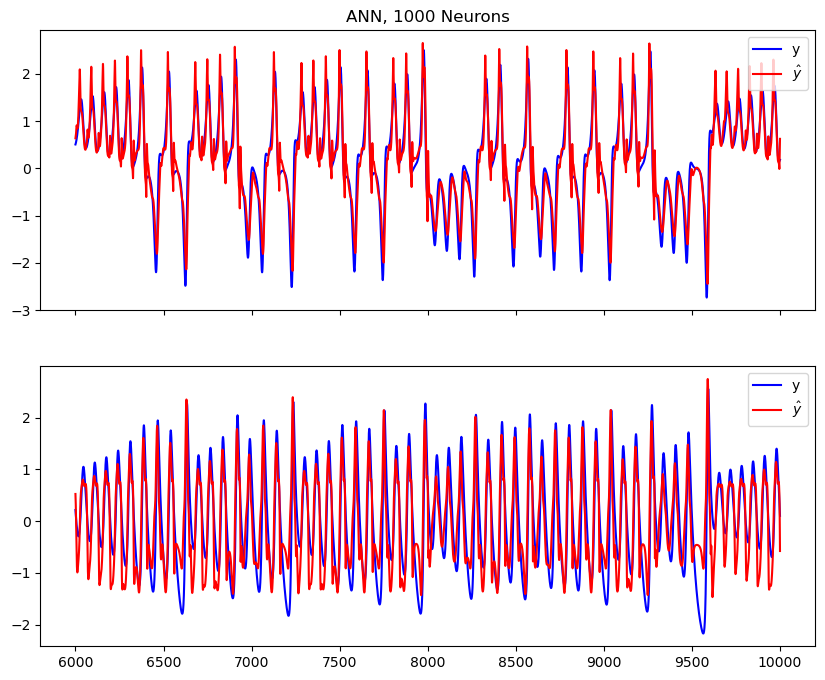

In [15]:
t_test = t[nt_train:]

fig, ax = plt.subplots(figsize=(10, 8), nrows=len(y_axes), sharex=True)

ax[0].set_title(f"ANN, {ann_res.n_hidden} Neurons")
for i_ax in range(len(ax)):
    ax[i_ax].plot(t_test, y_test[:, i_ax].cpu().numpy(), 'b-', label='y')
    ax[i_ax].plot(t_test, y_hat[:, i_ax].cpu().numpy(), 'r-', label=r'$\hat{y}$')
    ax[i_ax].legend(loc='upper right')
plt.show()

## Test Results

In [ ]:
from scipy.signal import find_peaks

dist = 300

peaks_orig = find_peaks(sup_test[:, 2].cpu().numpy(), distance=dist)[0]
peaks_snn = find_peaks(y_hat_mlc[:, 1].cpu().numpy().ravel(), distance=dist)[0]
peaks_ann = find_peaks(y_hat[:, 1].cpu().numpy().ravel(), distance=dist)[0]

vals_orig = sup_test[peaks_orig, 2].cpu().numpy()
vals_snn = y_hat_mlc.cpu().numpy().ravel()[peaks_snn]
vals_ann = y_hat.cpu().numpy().ravel()[peaks_ann]

NameError: name 'y_hat_mlc' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5), ncols=3)

# for i_ax in range(len(ax)):
ax[0].plot(vals_orig[:-1], vals_orig[1:], 'bo', ms=1)
ax[0].set_title("Original")
ax[1].plot(vals_ann[:-1], vals_ann[1:], 'bo', ms=1)
ax[1].set_title("ANN")
ax[2].plot(vals_snn[:-1], vals_snn[1:], 'bo', ms=1)
ax[2].set_title("SNN")

plt.show(fig)


NameError: name 'y_hat_mlc' is not defined

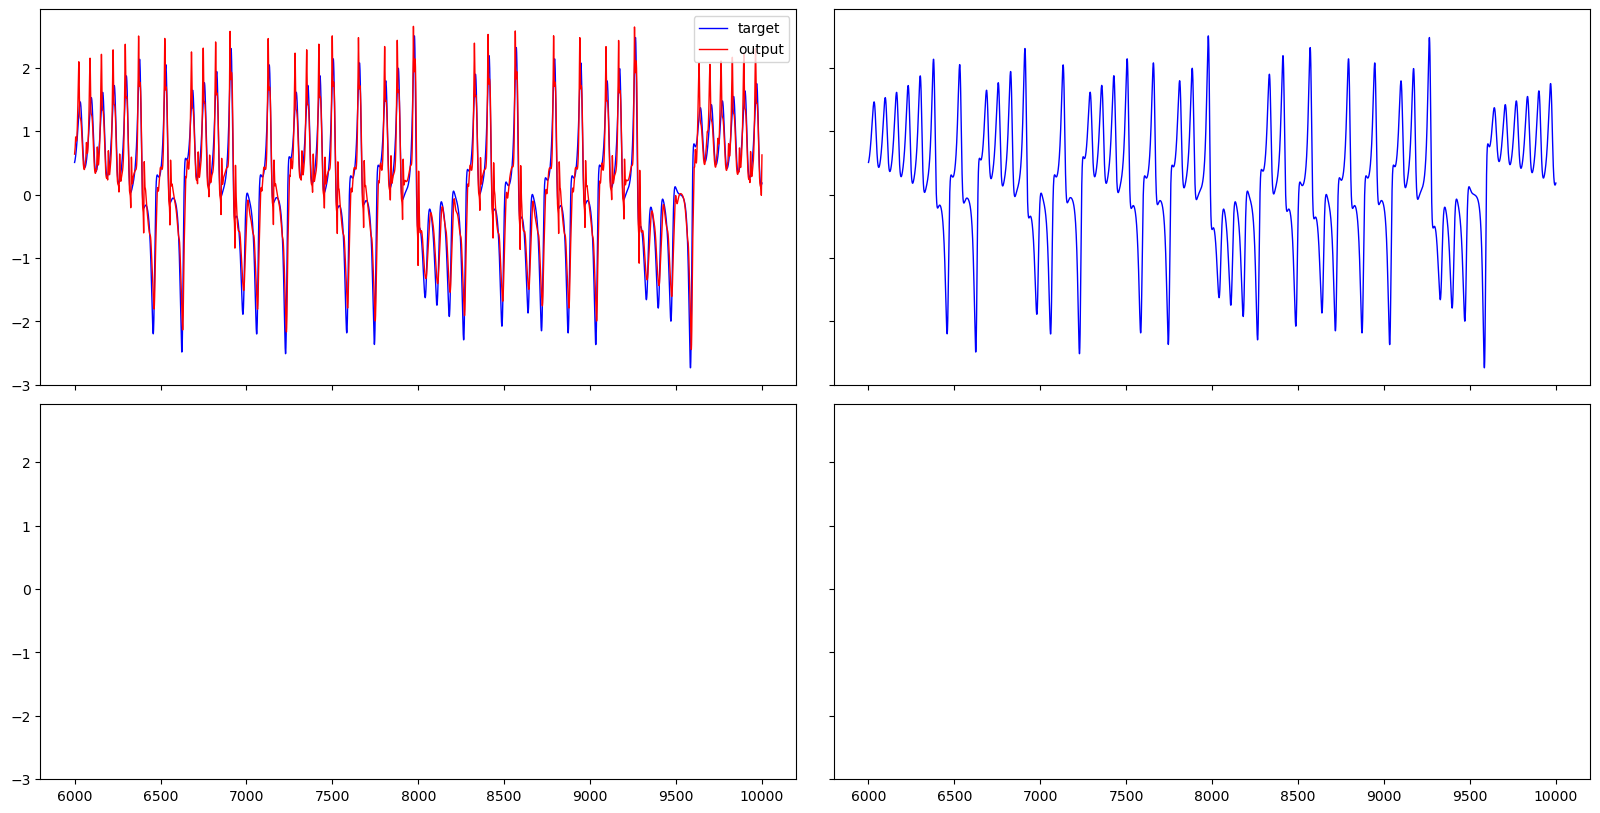

In [17]:
fig, ax = plt.subplots(figsize=(20, 10), nrows=len(y_axes), ncols=2, sharex=True, sharey=True)
lw = 1

fig.bbox_inches = 'tight'
fig.subplots_adjust(wspace=.05, hspace=.05)
for i in range(len(y_axes)):
    ax[i, 0].plot(t_test, y_test[:, i].cpu().numpy(), 'b-', lw=lw, label='target')
    ax[i, 0].plot(t_test, y_hat[:, i].cpu().numpy(), 'r-', lw=lw,label='output')
    ax[i, 0].legend(loc='upper right')
    ax[i, 1].plot(t_test, y_test[:, i].cpu().numpy(), 'b-', lw=lw, label='target')
    ax[i, 1].plot(t_test, y_hat_mlc[:, i].cpu().numpy(), 'r-', lw=lw, label='output')
    ax[i, 1].legend(loc='upper right')
    
ax[0, 0].set_title("ANN")
ax[0, 1].set_title("SNN")

plt.suptitle("Comparison of ANN vs. SNN Echo State Reservoirs\n"
             "Task: Curve Fitting", fontsize=16)
plt.show(fig)

# Echo State for Prediction Task

## ANN

In [68]:
dim = sup_tensor.size(1)
print(dim)

ann_ts = ANN_ESN(
    n_hidden=1000, n_output=dim, n_input=dim,
    device=device, dtype=torch.float32,
    w_in_amp=.3, w_res_amp=.06, bias=0.4
)

3


In [69]:
h_rec = ann_ts.fit(sup_train, closed_loop=True, l_ridge=1e-5)

  0%|          | 0/60000 [00:00<?, ?it/s]

100%|██████████| 60000/60000 [00:08<00:00, 6793.26it/s]


In [70]:
h_init = h_rec[-1].reshape(-1, 1)

h_init

tensor([[-0.4892],
        [ 0.8014],
        [ 0.8237],
        [-0.2924],
        [ 0.9992],
        [-0.9746],
        [-0.8104],
        [ 0.8861],
        [-0.7470],
        [ 0.9929],
        [ 0.4367],
        [ 0.5065],
        [-0.4501],
        [ 0.5378],
        [-0.6499],
        [ 0.8203],
        [ 0.9172],
        [ 0.1152],
        [-0.3207],
        [ 0.8202],
        [-0.8511],
        [-0.4096],
        [ 0.8294],
        [ 0.3945],
        [ 0.9674],
        [ 0.4359],
        [ 0.9452],
        [-0.0930],
        [-0.9893],
        [ 0.9738],
        [-0.9176],
        [ 0.0101],
        [ 0.8232],
        [ 0.8062],
        [ 0.7349],
        [-0.9882],
        [-0.8383],
        [ 0.9268],
        [-0.9410],
        [ 0.4460],
        [ 0.6650],
        [ 0.8735],
        [ 0.5236],
        [ 0.7175],
        [ 0.9859],
        [ 0.8116],
        [ 0.1532],
        [ 0.9214],
        [ 0.3693],
        [ 0.9755],
        [ 0.9913],
        [-0.6034],
        [ 0.

In [71]:
ann_out = ann_ts.predict(sup_test, closed_loop=True, h_init=h_init)

torch.Size([1000, 1000])


  0%|          | 0/40000 [00:00<?, ?it/s]

100%|██████████| 40000/40000 [00:04<00:00, 8066.00it/s]


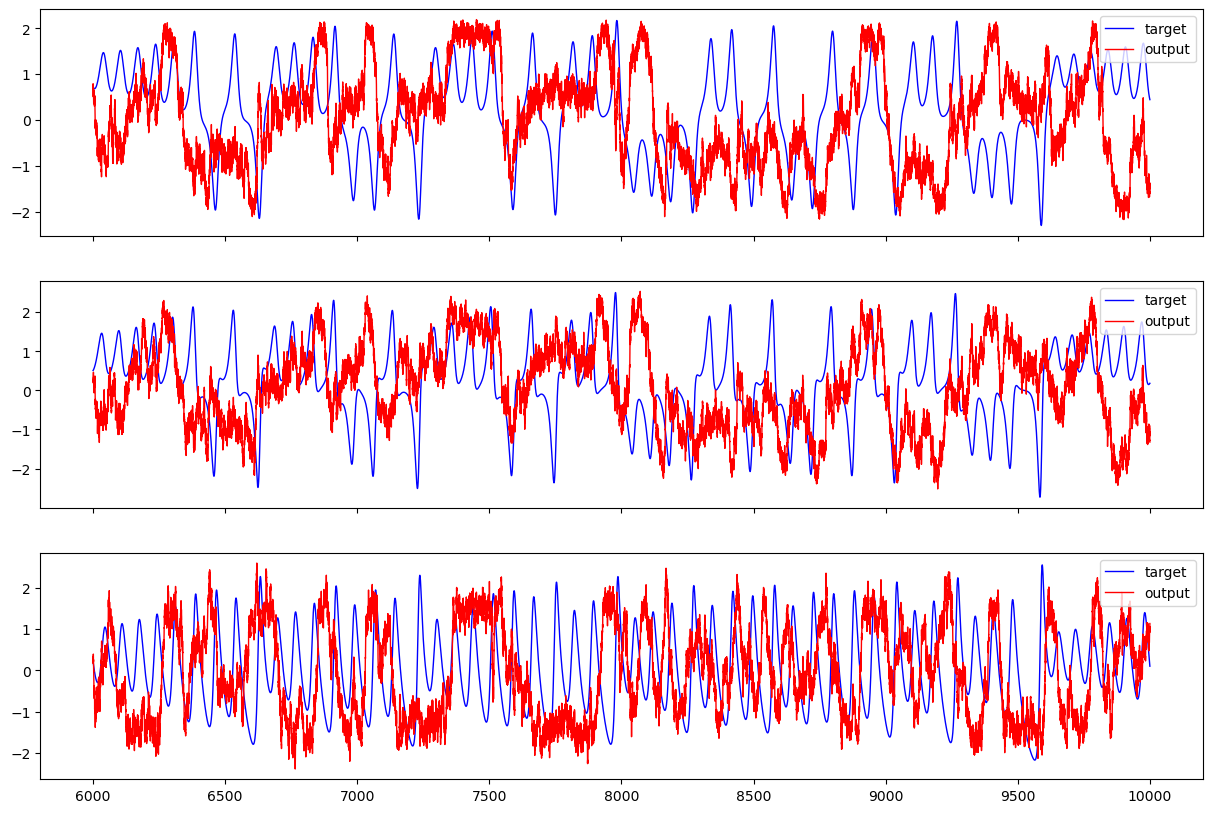

In [72]:
t_test = t[nt_train:]

fig, ax = plt.subplots(figsize=(15, 10), nrows=dim, sharex=True)
lw = 1

for i in range(dim):
    ax[i].plot(t_test, sup_test[:, i].cpu().numpy(), 'b-', label='target', lw=lw)
    ax[i].plot(t_test, ann_out[:, i].cpu().numpy(), 'r-', label='output', lw=lw)
    ax[i].legend(loc='upper right')

plt.show(fig)

## SNN

In [73]:
snn_ts = ML_ESN(
    MorrisLecarCurrent, n_input=sup_tensor.size(1), n_output=sup_tensor.size(1),
    BIAS=65, ne_hidden=Ne, ni_hidden=Ni, w_in_amp=Q, w_res_amp=gbar, device=device
)

In [74]:
snn_ts.fit(sup_train, nt_transient=int(500/dt), l_ridge=1e-5, closed_loop=True)

100%|██████████| 60000/60000 [00:30<00:00, 1979.68it/s]


tensor([[5.7876e-01, 1.3015e-02, 1.7720e-05,  ..., 9.4903e-01, 9.8195e-01,
         1.1945e-01],
        [5.7764e-01, 1.3096e-02, 1.7684e-05,  ..., 9.5273e-01, 9.8194e-01,
         1.1921e-01],
        [5.7651e-01, 1.3177e-02, 1.7649e-05,  ..., 9.5601e-01, 9.8194e-01,
         1.1898e-01],
        ...,
        [2.3612e-02, 6.4523e-02, 3.0164e-05,  ..., 9.7696e-01, 5.4854e-01,
         1.6480e-02],
        [2.3565e-02, 6.4394e-02, 3.0104e-05,  ..., 9.7691e-01, 5.4745e-01,
         1.6447e-02],
        [2.3518e-02, 6.4265e-02, 3.0044e-05,  ..., 9.7686e-01, 5.4635e-01,
         1.6414e-02]])

In [75]:
snn_out = snn_ts.predict(sup_test, closed_loop=True)

0it [00:00, ?it/s]
100%|██████████| 40000/40000 [00:18<00:00, 2179.86it/s]


In [76]:
snn_ts.W_out

tensor([[ 0.0030,  0.0252,  0.0143],
        [ 0.0195,  0.0157,  0.0032],
        [ 0.0046,  0.0093,  0.0018],
        ...,
        [ 0.0128,  0.0132, -0.0074],
        [-0.0062, -0.0074, -0.0035],
        [-0.0276, -0.0550,  0.0245]])

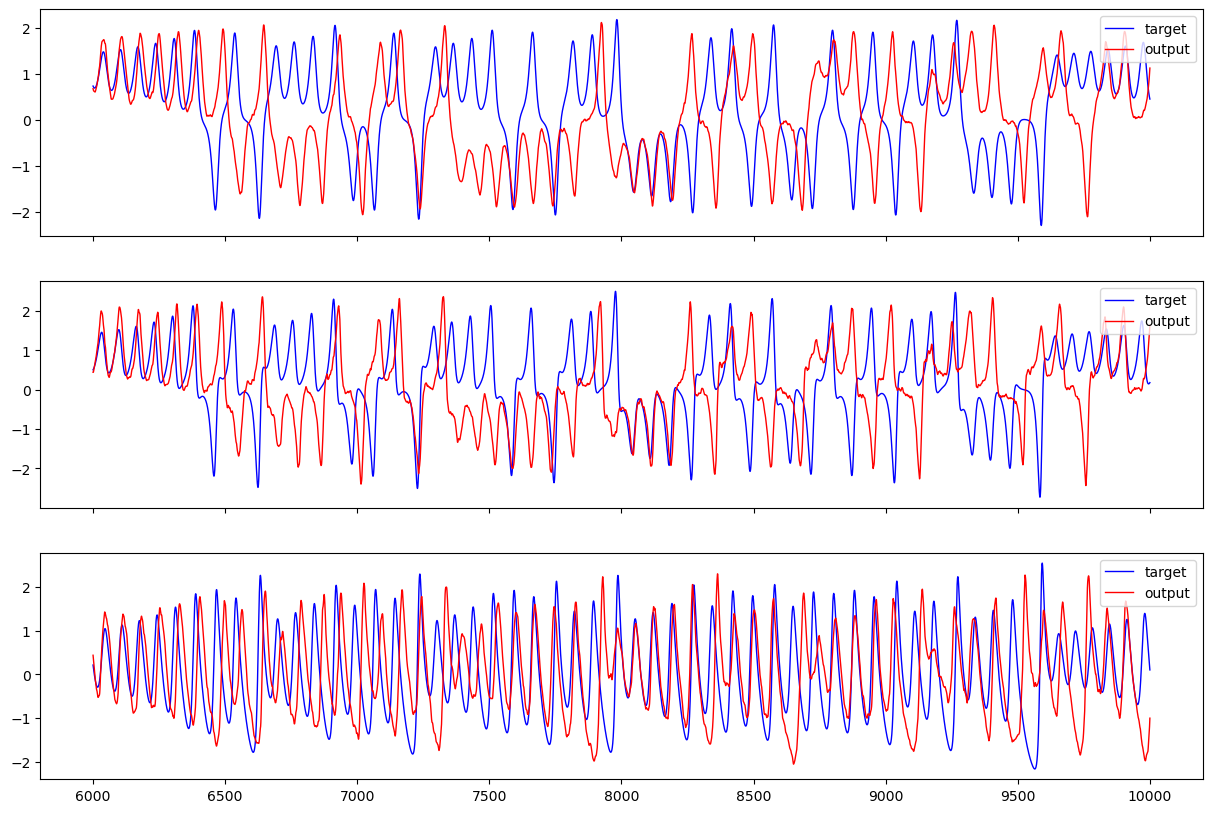

In [77]:
t_test = t[nt_train:]

fig, ax = plt.subplots(figsize=(15, 10), nrows=dim, sharex=True)
lw = 1

for i in range(dim):
    ax[i].plot(t_test, sup_test[:, i].cpu().numpy(), 'b-', label='target', lw=lw)
    ax[i].plot(t_test, snn_out[:, i].cpu().numpy(), 'r-', label='output', lw=lw)
    ax[i].legend(loc='upper right')

plt.show(fig)

## Test Results

In [78]:
from scipy.signal import find_peaks

dist = 200
prom = 0.0
peaks_orig = find_peaks(sup_test[:, 2].cpu().numpy(), distance=dist)[0]
peaks_snn = find_peaks(snn_out[:, 2].cpu().numpy().ravel(), distance=dist)[0]
peaks_ann = find_peaks(ann_out[:, 2].cpu().numpy().ravel(), distance=dist)[0]

vals_orig = sup_test[peaks_orig, 2].cpu().numpy()
vals_snn = snn_out.cpu().numpy().ravel()[peaks_snn]
vals_snn = vals_snn[vals_snn > 0]

vals_ann = ann_out.cpu().numpy().ravel()[peaks_ann]
vals_ann = vals_ann[vals_ann > 0]

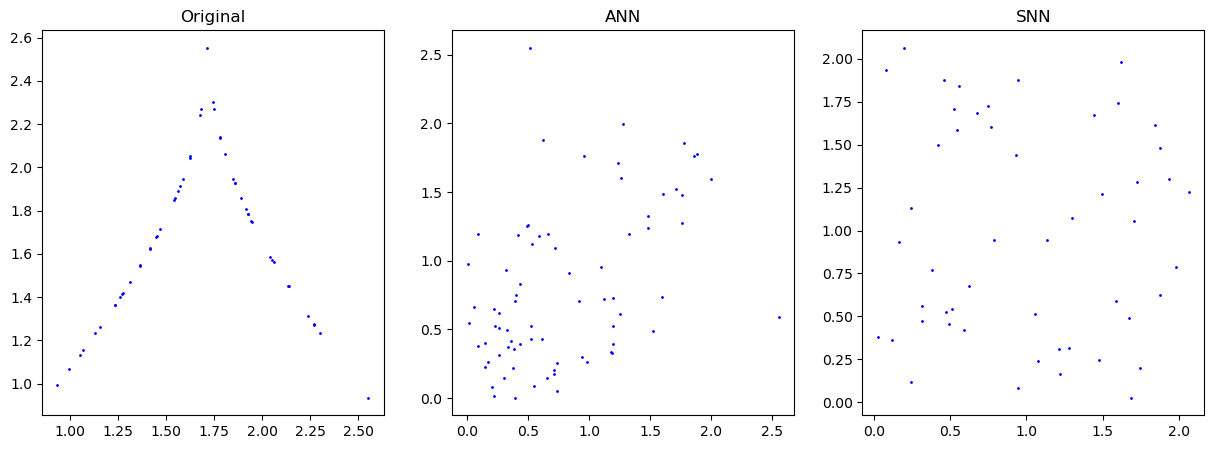

In [79]:
fig, ax = plt.subplots(figsize=(15, 5), ncols=3)

# for i_ax in range(len(ax)):
ax[0].plot(vals_orig[:-1], vals_orig[1:], 'bo', ms=1)
ax[0].set_title("Original")
ax[1].plot(vals_ann[:-1], vals_ann[1:], 'bo', ms=1)
ax[1].set_title("ANN")
ax[2].plot(vals_snn[:-1], vals_snn[1:], 'bo', ms=1)
ax[2].set_title("SNN")

plt.show(fig)


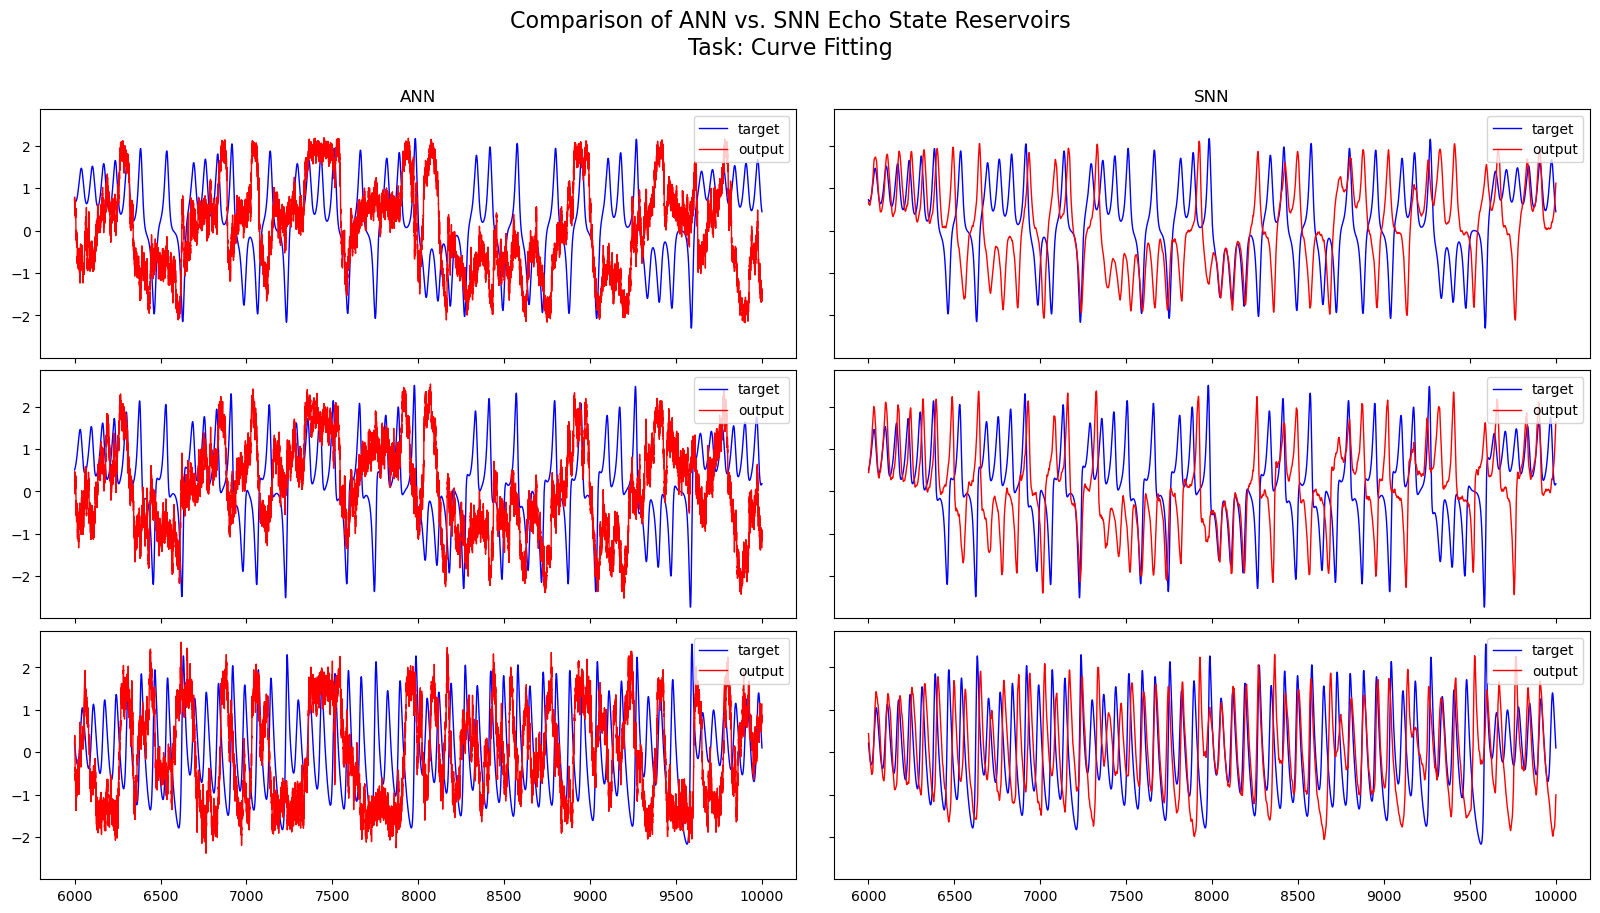

In [80]:
fig, ax = plt.subplots(figsize=(20, 10), ncols=2, nrows=sup_tensor.size(1), sharex=True, sharey=True)
lw = 1

fig.bbox_inches = 'tight'
fig.subplots_adjust(wspace=.05, hspace=.05)
for i in range(sup_tensor.size(1)):
    ax[i, 0].plot(t_test, sup_test[:, i].cpu().numpy(), 'b-', lw=lw, label='target')
    ax[i, 0].plot(t_test, ann_out[:, i].cpu().numpy(), 'r-', lw=lw,label='output')
    ax[i, 0].legend(loc='upper right')
    ax[i, 1].plot(t_test, sup_test[:, i].cpu().numpy(), 'b-', lw=lw, label='target')
    ax[i, 1].plot(t_test, snn_out[:, i].cpu().numpy(), 'r-', lw=lw, label='output')
    ax[i, 1].legend(loc='upper right')
    
ax[0, 0].set_title("ANN")
ax[0, 1].set_title("SNN")

plt.suptitle("Comparison of ANN vs. SNN Echo State Reservoirs\n"
             "Task: Curve Fitting", fontsize=16)
plt.show(fig)